# DataDialogue AI - Base de Datos Bancaria

## Propósito
Construir una base de datos relacional de ejemplo para un banco, con el fin de servir como base de un sistema de consulta en lenguaje natural por texto y voz.

## Tablas del modelo
- **clientes**: información básica de los clientes.
- **ciudad**: catálogo de ciudades.
- **cuentas**: productos bancarios asociados a cada cliente.
- **movimientos**: transacciones realizadas sobre las cuentas.

## Objetivo técnico de esta fase
1. Crear la base de datos desde Python.
2. Definir tablas y relaciones.
3. Insertar datos de ejemplo.
4. Verificar consultas SQL.
"""))

In [1]:
# ============================================================
# LIBRERÍAS
# ============================================================

import sqlite3
import pandas as pd
from datetime import datetime

In [2]:
# ============================================================
# CREAR / CONECTAR BASE DE DATOS
# ============================================================

nombre_bd = "banco.db"

conn = sqlite3.connect(nombre_bd)
cursor = conn.cursor()

print(f"Base de datos '{nombre_bd}' creada y conectada correctamente.")

Base de datos 'banco.db' creada y conectada correctamente.


In [3]:
# ============================================================
# ACTIVAR FOREIGN KEYS
# ============================================================

cursor.execute("PRAGMA foreign_keys = ON;")
print("Integridad referencial activada.")

Integridad referencial activada.


In [4]:
# ============================================================
# ELIMINAR TABLAS SI YA EXISTEN
# ============================================================

cursor.executescript("""
DROP TABLE IF EXISTS movimientos;
DROP TABLE IF EXISTS cuentas;
DROP TABLE IF EXISTS clientes;
DROP TABLE IF EXISTS ciudad;
""")

conn.commit()
print("Tablas anteriores eliminadas correctamente.")

Tablas anteriores eliminadas correctamente.


In [5]:
# ============================================================
# TABLA: ciudad
# ============================================================


cursor.execute("""
CREATE TABLE ciudad (
    id_ciudad INTEGER PRIMARY KEY AUTOINCREMENT,
    nombre_ciudad TEXT NOT NULL,
    departamento TEXT NOT NULL
);
""")

print("Tabla 'ciudad' creada correctamente.")

Tabla 'ciudad' creada correctamente.


In [6]:
# ============================================================
# TABLA: clientes
# ============================================================

cursor.execute("""
CREATE TABLE clientes (
    id_cliente INTEGER PRIMARY KEY AUTOINCREMENT,
    nombre TEXT NOT NULL,
    apellido TEXT NOT NULL,
    documento TEXT NOT NULL UNIQUE,
    fecha_nacimiento TEXT NOT NULL,
    id_ciudad INTEGER NOT NULL,
    telefono TEXT,
    correo TEXT,
    FOREIGN KEY (id_ciudad) REFERENCES ciudad(id_ciudad)
);
""")

print("Tabla 'clientes' creada correctamente.")

Tabla 'clientes' creada correctamente.


In [7]:
# ============================================================
# TABLA: cuentas
# ============================================================

cursor.execute("""
CREATE TABLE cuentas (
    id_cuenta INTEGER PRIMARY KEY AUTOINCREMENT,
    id_cliente INTEGER NOT NULL,
    tipo_cuenta TEXT NOT NULL,
    saldo REAL NOT NULL,
    fecha_apertura TEXT NOT NULL,
    estado TEXT NOT NULL,
    FOREIGN KEY (id_cliente) REFERENCES clientes(id_cliente)
);
""")

print("Tabla 'cuentas' creada correctamente.")

Tabla 'cuentas' creada correctamente.


In [8]:
# ============================================================
# TABLA: movimientos
# ============================================================

cursor.execute("""
CREATE TABLE movimientos (
    id_movimiento INTEGER PRIMARY KEY AUTOINCREMENT,
    id_cuenta INTEGER NOT NULL,
    fecha_movimiento TEXT NOT NULL,
    tipo_movimiento TEXT NOT NULL,
    valor REAL NOT NULL,
    descripcion TEXT,
    FOREIGN KEY (id_cuenta) REFERENCES cuentas(id_cuenta)
);
""")

print("Tabla 'movimientos' creada correctamente.")

Tabla 'movimientos' creada correctamente.


In [9]:
conn.commit()
print("Modelo relacional creado exitosamente.")

Modelo relacional creado exitosamente.


In [10]:
# ============================================================
# INSERTAR DATOS EN ciudad
# ============================================================

ciudades = [
    ("Bogotá", "Cundinamarca"),
    ("Medellín", "Antioquia"),
    ("Cali", "Valle del Cauca"),
    ("Manizales", "Caldas"),
    ("Barranquilla", "Atlántico")
]

cursor.executemany("""
INSERT INTO ciudad (nombre_ciudad, departamento)
VALUES (?, ?)
""", ciudades)

conn.commit()
print("Datos insertados en 'ciudad'.")

Datos insertados en 'ciudad'.


In [11]:
# ============================================================
# INSERTAR DATOS EN clientes
# ============================================================

clientes = [
    ("Ana", "Gómez", "1001", "1990-05-10", 1, "3001111111", "ana@correo.com"),
    ("Luis", "Martínez", "1002", "1988-07-21", 2, "3002222222", "luis@correo.com"),
    ("Carla", "Ramírez", "1003", "1995-03-14", 3, "3003333333", "carla@correo.com"),
    ("Jorge", "López", "1004", "1982-11-30", 4, "3004444444", "jorge@correo.com"),
    ("María", "Torres", "1005", "1998-09-08", 1, "3005555555", "maria@correo.com")
]

cursor.executemany("""
INSERT INTO clientes (nombre, apellido, documento, fecha_nacimiento, id_ciudad, telefono, correo)
VALUES (?, ?, ?, ?, ?, ?, ?)
""", clientes)

conn.commit()
print("Datos insertados en 'clientes'.")

Datos insertados en 'clientes'.


In [12]:
# ============================================================
# INSERTAR DATOS EN cuentas
# ============================================================

cuentas = [
    (1, "Ahorros",   2500000, "2023-01-15", "Activa"),
    (1, "Corriente", 1200000, "2024-02-10", "Activa"),
    (2, "Ahorros",   3400000, "2022-08-05", "Activa"),
    (3, "Ahorros",    850000, "2024-01-22", "Activa"),
    (4, "Corriente", 5600000, "2021-11-01", "Activa"),
    (5, "Ahorros",   1750000, "2023-09-17", "Inactiva")
]

cursor.executemany("""
INSERT INTO cuentas (id_cliente, tipo_cuenta, saldo, fecha_apertura, estado)
VALUES (?, ?, ?, ?, ?)
""", cuentas)

conn.commit()
print("Datos insertados en 'cuentas'.")

Datos insertados en 'cuentas'.


In [13]:
# ============================================================
# INSERTAR DATOS EN movimientos
# ============================================================

movimientos = [
    (1, "2026-04-01", "Consignación", 500000, "Pago de nómina"),
    (1, "2026-04-02", "Retiro", -200000, "Retiro cajero"),
    (2, "2026-04-03", "Transferencia", -150000, "Pago servicios"),
    (3, "2026-04-03", "Consignación", 800000, "Ingreso adicional"),
    (4, "2026-04-04", "Retiro", -100000, "Compra supermercado"),
    (5, "2026-04-05", "Consignación", 1200000, "Pago proveedor"),
    (1, "2026-04-06", "Transferencia", -300000, "Transferencia a tercero"),
    (3, "2026-04-06", "Retiro", -250000, "Retiro ventanilla"),
    (4, "2026-04-07", "Consignación", 400000, "Abono"),
    (6, "2026-04-07", "Retiro", -50000, "Débito automático")
]

cursor.executemany("""
INSERT INTO movimientos (id_cuenta, fecha_movimiento, tipo_movimiento, valor, descripcion)
VALUES (?, ?, ?, ?, ?)
""", movimientos)

conn.commit()
print("Datos insertados en 'movimientos'.")

Datos insertados en 'movimientos'.


In [14]:
# ============================================================
# VER DATOS DE ciudad
# ============================================================

df_ciudad = pd.read_sql_query("SELECT * FROM ciudad", conn)
df_ciudad

,id_ciudad,nombre_ciudad,departamento
0,1,Bogotá,Cundinamarca
1,2,Medellín,Antioquia
2,3,Cali,Valle del Cauca
3,4,Manizales,Caldas
4,5,Barranquilla,Atlántico


In [15]:
# ============================================================
# VER DATOS DE cuentas
# ============================================================

df_cuentas = pd.read_sql_query("SELECT * FROM cuentas", conn)
df_cuentas

,id_cuenta,id_cliente,tipo_cuenta,saldo,fecha_apertura,estado
0,1,1,Ahorros,2500000.0,2023-01-15,Activa
1,2,1,Corriente,1200000.0,2024-02-10,Activa
2,3,2,Ahorros,3400000.0,2022-08-05,Activa
3,4,3,Ahorros,850000.0,2024-01-22,Activa
4,5,4,Corriente,5600000.0,2021-11-01,Activa
5,6,5,Ahorros,1750000.0,2023-09-17,Inactiva


In [16]:
# ============================================================
# VER DATOS DE movimientos
# ============================================================

df_movimientos = pd.read_sql_query("SELECT * FROM movimientos", conn)
df_movimientos

,id_movimiento,id_cuenta,fecha_movimiento,tipo_movimiento,valor,descripcion
0,1,1,2026-04-01,Consignación,500000.0,Pago de nómina
1,2,1,2026-04-02,Retiro,-200000.0,Retiro cajero
2,3,2,2026-04-03,Transferencia,-150000.0,Pago servicios
3,4,3,2026-04-03,Consignación,800000.0,Ingreso adicional
4,5,4,2026-04-04,Retiro,-100000.0,Compra supermercado
5,6,5,2026-04-05,Consignación,1200000.0,Pago proveedor
6,7,1,2026-04-06,Transferencia,-300000.0,Transferencia a tercero
7,8,3,2026-04-06,Retiro,-250000.0,Retiro ventanilla
8,9,4,2026-04-07,Consignación,400000.0,Abono
9,10,6,2026-04-07,Retiro,-50000.0,Débito automático


In [17]:
# ============================================================
# CONSULTA 1: CLIENTES Y SU CIUDAD
# ============================================================

consulta_1 = """
SELECT
    c.id_cliente,
    c.nombre,
    c.apellido,
    ci.nombre_ciudad,
    ci.departamento
FROM clientes c
INNER JOIN ciudad ci
    ON c.id_ciudad = ci.id_ciudad
ORDER BY c.id_cliente;
"""

pd.read_sql_query(consulta_1, conn)

,id_cliente,nombre,apellido,nombre_ciudad,departamento
0,1,Ana,Gómez,Bogotá,Cundinamarca
1,2,Luis,Martínez,Medellín,Antioquia
2,3,Carla,Ramírez,Cali,Valle del Cauca
3,4,Jorge,López,Manizales,Caldas
4,5,María,Torres,Bogotá,Cundinamarca


In [18]:
# ============================================================
# CONSULTA 2: CUENTAS POR CLIENTE
# ============================================================

consulta_2 = """
SELECT
    cl.nombre || ' ' || cl.apellido AS cliente,
    cu.id_cuenta,
    cu.tipo_cuenta,
    cu.saldo,
    cu.estado
FROM cuentas cu
INNER JOIN clientes cl
    ON cu.id_cliente = cl.id_cliente
ORDER BY cliente;
"""

pd.read_sql_query(consulta_2, conn)

,cliente,id_cuenta,tipo_cuenta,saldo,estado
0,Ana Gómez,1,Ahorros,2500000.0,Activa
1,Ana Gómez,2,Corriente,1200000.0,Activa
2,Carla Ramírez,4,Ahorros,850000.0,Activa
3,Jorge López,5,Corriente,5600000.0,Activa
4,Luis Martínez,3,Ahorros,3400000.0,Activa
5,María Torres,6,Ahorros,1750000.0,Inactiva


In [19]:
# ============================================================
# CONSULTA 3: MOVIMIENTOS CON CLIENTE
# ============================================================

consulta_3 = """
SELECT
    m.id_movimiento,
    cl.nombre || ' ' || cl.apellido AS cliente,
    cu.id_cuenta,
    m.fecha_movimiento,
    m.tipo_movimiento,
    m.valor,
    m.descripcion
FROM movimientos m
INNER JOIN cuentas cu
    ON m.id_cuenta = cu.id_cuenta
INNER JOIN clientes cl
    ON cu.id_cliente = cl.id_cliente
ORDER BY m.fecha_movimiento;
"""

pd.read_sql_query(consulta_3, conn)

,id_movimiento,cliente,id_cuenta,fecha_movimiento,tipo_movimiento,valor,descripcion
0,1,Ana Gómez,1,2026-04-01,Consignación,500000.0,Pago de nómina
1,2,Ana Gómez,1,2026-04-02,Retiro,-200000.0,Retiro cajero
2,3,Ana Gómez,2,2026-04-03,Transferencia,-150000.0,Pago servicios
3,4,Luis Martínez,3,2026-04-03,Consignación,800000.0,Ingreso adicional
4,5,Carla Ramírez,4,2026-04-04,Retiro,-100000.0,Compra supermercado
5,6,Jorge López,5,2026-04-05,Consignación,1200000.0,Pago proveedor
6,7,Ana Gómez,1,2026-04-06,Transferencia,-300000.0,Transferencia a tercero
7,8,Luis Martínez,3,2026-04-06,Retiro,-250000.0,Retiro ventanilla
8,9,Carla Ramírez,4,2026-04-07,Consignación,400000.0,Abono
9,10,María Torres,6,2026-04-07,Retiro,-50000.0,Débito automático


In [20]:
# ============================================================
# CONSULTA 4: SALDO TOTAL POR CIUDAD
# ============================================================

consulta_4 = """
SELECT
    ci.nombre_ciudad,
    SUM(cu.saldo) AS saldo_total
FROM cuentas cu
INNER JOIN clientes cl
    ON cu.id_cliente = cl.id_cliente
INNER JOIN ciudad ci
    ON cl.id_ciudad = ci.id_ciudad
GROUP BY ci.nombre_ciudad
ORDER BY saldo_total DESC;
"""

pd.read_sql_query(consulta_4, conn)

,nombre_ciudad,saldo_total
0,Manizales,5600000.0
1,Bogotá,5450000.0
2,Medellín,3400000.0
3,Cali,850000.0


In [21]:
# ============================================================
# CONSULTA 5: MOVIMIENTOS POR TIPO
# ============================================================

consulta_5 = """
SELECT
    tipo_movimiento,
    COUNT(*) AS cantidad_movimientos,
    SUM(valor) AS valor_total
FROM movimientos
GROUP BY tipo_movimiento
ORDER BY cantidad_movimientos DESC;
"""

pd.read_sql_query(consulta_5, conn)

,tipo_movimiento,cantidad_movimientos,valor_total
0,Retiro,4,-600000.0
1,Consignación,4,2900000.0
2,Transferencia,2,-450000.0


In [22]:
# ============================================================
# VER TABLAS DE LA BASE DE DATOS
# ============================================================

tablas = pd.read_sql_query("""
SELECT name
FROM sqlite_master
WHERE type='table';
""", conn)

tablas

,name
0,ciudad
1,sqlite_sequence
2,clientes
3,cuentas
4,movimientos


In [23]:
# ============================================================
# ESTRUCTURA DE LA TABLA clientes
# ============================================================

pd.read_sql_query("PRAGMA table_info(clientes);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,id_cliente,INTEGER,0,None,1
1,1,nombre,TEXT,1,None,0
2,2,apellido,TEXT,1,None,0
3,3,documento,TEXT,1,None,0
4,4,fecha_nacimiento,TEXT,1,None,0
5,5,id_ciudad,INTEGER,1,None,0
6,6,telefono,TEXT,0,None,0
7,7,correo,TEXT,0,None,0


In [24]:
pd.read_sql_query("PRAGMA table_info(cuentas);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,id_cuenta,INTEGER,0,None,1
1,1,id_cliente,INTEGER,1,None,0
2,2,tipo_cuenta,TEXT,1,None,0
3,3,saldo,REAL,1,None,0
4,4,fecha_apertura,TEXT,1,None,0
5,5,estado,TEXT,1,None,0


In [25]:
pd.read_sql_query("PRAGMA table_info(movimientos);", conn)

,cid,name,type,notnull,dflt_value,pk
0,0,id_movimiento,INTEGER,0,None,1
1,1,id_cuenta,INTEGER,1,None,0
2,2,fecha_movimiento,TEXT,1,None,0
3,3,tipo_movimiento,TEXT,1,None,0
4,4,valor,REAL,1,None,0
5,5,descripcion,TEXT,0,None,0


In [26]:
# ============================================================
# FUNCIÓN PARA EJECUTAR CONSULTAS SQL
# ============================================================

def ejecutar_sql(query):
    """
    Ejecuta una consulta SQL sobre la base de datos SQLite
    y devuelve el resultado en un DataFrame de pandas.
    """
    try:
        resultado = pd.read_sql_query(query, conn)
        return resultado
    except Exception as e:
        print("Error al ejecutar la consulta:", e)

In [27]:
query_prueba = """
SELECT nombre, apellido, correo
FROM clientes;
"""

ejecutar_sql(query_prueba)

,nombre,apellido,correo
0,Ana,Gómez,ana@correo.com
1,Luis,Martínez,luis@correo.com
2,Carla,Ramírez,carla@correo.com
3,Jorge,López,jorge@correo.com
4,María,Torres,maria@correo.com


In [28]:
# ============================================================
# DICCIONARIO SEMÁNTICO INICIAL
# ============================================================

diccionario_semantico = {
    "clientes": "Personas registradas en el banco",
    "cuentas": "Productos financieros asociados a clientes",
    "movimientos": "Transacciones realizadas en cuentas",
    "ciudad": "Ubicación geográfica del cliente",
    "saldo": "Dinero actual en una cuenta",
    "consignación": "Ingreso de dinero a una cuenta",
    "retiro": "Salida de dinero de una cuenta",
    "transferencia": "Movimiento de dinero hacia otra cuenta o destino"
}

diccionario_semantico

{'clientes': 'Personas registradas en el banco',
 'cuentas': 'Productos financieros asociados a clientes',
 'movimientos': 'Transacciones realizadas en cuentas',
 'ciudad': 'Ubicación geográfica del cliente',
 'saldo': 'Dinero actual en una cuenta',
 'consignación': 'Ingreso de dinero a una cuenta',
 'retiro': 'Salida de dinero de una cuenta',
 'transferencia': 'Movimiento de dinero hacia otra cuenta o destino'}

In [29]:
# ============================================================
# CERRAR CONEXIÓN
# ============================================================

conn.close()
print("Conexión cerrada correctamente.")

Conexión cerrada correctamente.


# **PARTE 2**
# **Capa de chat sobre la base de datos bancaria**

**NOTEBOOK 2: CAPA DE CHAT SOBRE LA BD BANCARIA**

Proyecto: DataDialogue AI

**Objetivo:**

Permitir consultas en lenguaje natural sobre la base de datos bancaria y transformarlas en consultas SQL ejecutables.

# DataDialogue AI - Capa de Chat

## Propósito
Construir una primera capa conversacional para consultar una base de datos bancaria mediante lenguaje natural.

## Flujo funcional
1. El usuario escribe una pregunta.
2. El sistema interpreta la intención.
3. Se genera una consulta SQL.
4. La consulta se ejecuta sobre la BD.
5. El sistema devuelve el resultado en forma comprensible.

## Alcance de esta fase
- Consulta por texto
- Traducción NL → SQL
- Ejecución controlada
- Respuesta amigable

Aquí instalamos:

langchain: framework de orquestación

langchain-openai: conexión con modelos de OpenAI

langchain-community: utilidades comunitarias

sqlalchemy: conexión robusta a SQLite

pandas: visualización de resultados

In [30]:
# ============================================================
# INSTALACIÓN DE DEPENDENCIAS
# ============================================================

!pip install -q -U langchain langchain-core langchain-openai langchain-community sqlalchemy pandas

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 515.9/515.9 kB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.6/98.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 21.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 49.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 35.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 51.0/51.0 kB 3.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 3.0.2 which is incompatible.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.33.1 which is incompatible.
gradio 5

In [31]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os
import sqlite3
import pandas as pd
from IPython.display import display
from sqlalchemy import create_engine, text

from langchain_openai import ChatOpenAI
from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

In [32]:
esquema_bd = """
Base de datos: banco

Tablas:
- ciudad(id_ciudad, nombre_ciudad, departamento)
- clientes(id_cliente, nombre, apellido, documento, fecha_nacimiento, id_ciudad, telefono, correo)
- cuentas(id_cuenta, id_cliente, tipo_cuenta, saldo, fecha_apertura, estado)
- movimientos(id_movimiento, id_cuenta, fecha_movimiento, tipo_movimiento, valor, descripcion)

Relaciones:
- clientes.id_ciudad = ciudad.id_ciudad
- cuentas.id_cliente = clientes.id_cliente
- movimientos.id_cuenta = cuentas.id_cuenta
"""

In [33]:
# ============================================================
# CONEXIÓN A LA BASE DE DATOS
# ============================================================

# sqlite3 para consultas sencillas con pandas
# sqlalchemy porque es muy útil para integración con cadenas de IA

ruta_bd = "banco.db"

conn = sqlite3.connect(ruta_bd)
engine = create_engine(f"sqlite:///{ruta_bd}")

print(f"Conexión establecida correctamente con la base de datos: {ruta_bd}")

Conexión establecida correctamente con la base de datos: banco.db


In [34]:
# ============================================================
# VERIFICAR TABLAS DISPONIBLES
# ============================================================

query_tablas = """
SELECT name
FROM sqlite_master
WHERE type='table';
"""

df_tablas = pd.read_sql_query(query_tablas, conn)
df_tablas

,name
0,ciudad
1,sqlite_sequence
2,clientes
3,cuentas
4,movimientos


In [35]:
# ============================================================
# DATOS DE PRUEBA
# ============================================================

pd.read_sql_query("SELECT * FROM clientes LIMIT 5;", conn)

,id_cliente,nombre,apellido,documento,fecha_nacimiento,id_ciudad,telefono,correo
0,1,Ana,Gómez,1001,1990-05-10,1,3001111111,ana@correo.com
1,2,Luis,Martínez,1002,1988-07-21,2,3002222222,luis@correo.com
2,3,Carla,Ramírez,1003,1995-03-14,3,3003333333,carla@correo.com
3,4,Jorge,López,1004,1982-11-30,4,3004444444,jorge@correo.com
4,5,María,Torres,1005,1998-09-08,1,3005555555,maria@correo.com


In [36]:
# ============================================================
# DESCRIPCIÓN SEMÁNTICA DEL ESQUEMA
# ============================================================

esquema_bd = """
Base de datos: banco

Tablas:

1. ciudad
- id_ciudad: identificador de la ciudad
- nombre_ciudad: nombre de la ciudad
- departamento: departamento de la ciudad

2. clientes
- id_cliente: identificador del cliente
- nombre: nombre del cliente
- apellido: apellido del cliente
- documento: número de documento
- fecha_nacimiento: fecha de nacimiento
- id_ciudad: ciudad donde reside el cliente
- telefono: número de teléfono
- correo: correo electrónico

3. cuentas
- id_cuenta: identificador de la cuenta
- id_cliente: cliente dueño de la cuenta
- tipo_cuenta: Ahorros o Corriente
- saldo: saldo actual
- fecha_apertura: fecha de apertura de la cuenta
- estado: estado de la cuenta. Valores válidos: Activa, Inactiva

4. movimientos
- id_movimiento: identificador del movimiento
- id_cuenta: cuenta asociada al movimiento
- fecha_movimiento: fecha del movimiento
- tipo_movimiento: valores válidos: Consignación, Retiro, Transferencia
- valor: valor del movimiento
- descripcion: detalle del movimiento

Relaciones:
- clientes.id_ciudad -> ciudad.id_ciudad
- cuentas.id_cliente -> clientes.id_cliente
- movimientos.id_cuenta -> cuentas.id_cuenta
"""
print(esquema_bd)


Base de datos: banco

Tablas:

1. ciudad
- id_ciudad: identificador de la ciudad
- nombre_ciudad: nombre de la ciudad
- departamento: departamento de la ciudad

2. clientes
- id_cliente: identificador del cliente
- nombre: nombre del cliente
- apellido: apellido del cliente
- documento: número de documento
- fecha_nacimiento: fecha de nacimiento
- id_ciudad: ciudad donde reside el cliente
- telefono: número de teléfono
- correo: correo electrónico

3. cuentas
- id_cuenta: identificador de la cuenta
- id_cliente: cliente dueño de la cuenta
- tipo_cuenta: Ahorros o Corriente
- saldo: saldo actual
- fecha_apertura: fecha de apertura de la cuenta
- estado: estado de la cuenta. Valores válidos: Activa, Inactiva

4. movimientos
- id_movimiento: identificador del movimiento
- id_cuenta: cuenta asociada al movimiento
- fecha_movimiento: fecha del movimiento
- tipo_movimiento: valores válidos: Consignación, Retiro, Transferencia
- valor: valor del movimiento
- descripcion: detalle del movimien

In [37]:
import os

os.environ["OPENAI_API_KEY"] = "YOUR_OPENAI_API_KEY_HERE"

In [38]:
# ============================================================
# MODELO DE LENGUAJE
# ============================================================

llm = ChatOpenAI(
    model="gpt-4.1-mini",
    temperature=0
)

print("Modelo cargado correctamente.")

Modelo cargado correctamente.


In [39]:
# ============================================================
# PROMPT PARA GENERAR SQL
# ============================================================

prompt_sql = PromptTemplate(
    input_variables=["esquema_bd", "pregunta_usuario"],
    template="""
Eres un experto en SQL para SQLite.

Tu tarea es convertir la pregunta del usuario en una consulta SQL válida
para SQLite, usando exclusivamente el esquema proporcionado.

Reglas obligatorias:
1. Usa solo tablas y columnas existentes en el esquema.
2. No inventes nombres de tablas ni campos.
3. Genera únicamente una consulta SQL.
4. No incluyas explicaciones.
5. No uses markdown.
6. Si la pregunta requiere texto, usa LIKE cuando sea apropiado.
7. Si se necesita unir tablas, usa JOIN correctamente.
8. Limita a 100 filas como máximo cuando aplique.
9. Nunca uses DROP, DELETE, UPDATE, INSERT o ALTER.
10. Solo genera consultas SELECT.
11. Respeta exactamente los valores categóricos del esquema, incluyendo mayúsculas, tildes y género cuando estén definidos.

Esquema:
{esquema_bd}

Pregunta del usuario:
{pregunta_usuario}

SQL:
"""
)

print("Prompt de generación SQL listo.")

Prompt de generación SQL listo.


In [40]:
# ============================================================
# CADENA PARA GENERAR SQL
# ============================================================

cadena_sql = prompt_sql | llm | StrOutputParser()

print("Cadena SQL creada correctamente.")

Cadena SQL creada correctamente.


In [41]:
# ============================================================
# FUNCIÓN: GENERAR SQL DESDE LENGUAJE NATURAL
# ============================================================

def generar_sql(pregunta_usuario: str) -> str:
    """
    Recibe una pregunta en lenguaje natural y devuelve
    una consulta SQL generada por el modelo.
    """
    sql_generado = cadena_sql.invoke({
        "esquema_bd": esquema_bd,
        "pregunta_usuario": pregunta_usuario
    })
    return sql_generado.strip()

In [42]:
# Prueba de consulta del chat al sql
pregunta_prueba = "¿clientes de bogota?"
sql_prueba = generar_sql(pregunta_prueba)

print("Pregunta:", pregunta_prueba)
print("\nSQL generado:\n")
print(sql_prueba)

Pregunta: ¿clientes de bogota?

SQL generado:

SELECT * FROM clientes JOIN ciudad ON clientes.id_ciudad = ciudad.id_ciudad WHERE ciudad.nombre_ciudad = 'Bogota' LIMIT 100;


In [43]:
# ============================================================
# FUNCIÓN: EJECUTAR SQL
# ============================================================

def ejecutar_sql_seguro(sql_query: str) -> pd.DataFrame:
    """
    Ejecuta una consulta SQL SELECT sobre la base de datos
    y devuelve el resultado como DataFrame.
    """
    sql_limpio = sql_query.strip().lower()

    if not sql_limpio.startswith("select"):
        raise ValueError("Solo se permiten consultas SELECT.")

    bloqueadas = ["drop ", "delete ", "update ", "insert ", "alter "]
    if any(palabra in sql_limpio for palabra in bloqueadas):
        raise ValueError("La consulta contiene instrucciones no permitidas.")

    return pd.read_sql_query(sql_query, conn)

In [44]:
# ============================================================
# PRUEBA INTERACTIVA: PREGUNTA LIBRE DEL USUARIO
# ============================================================

pregunta_usuario = input("Escribe tu pregunta sobre la base de datos bancaria: ")

try:
    # 1. Generar SQL
    sql_generado = generar_sql(pregunta_usuario)

    print("\n" + "="*70)
    print("PREGUNTA DEL USUARIO:")
    print(pregunta_usuario)

    print("\n" + "="*70)
    print("SQL GENERADO:")
    print(sql_generado)

    # 2. Ejecutar SQL
    resultado = ejecutar_sql_seguro(sql_generado)

    print("\n" + "="*70)
    print("RESULTADO:")
    display(resultado)

    # 3. Mensaje simple de interpretación
    print("\n" + "="*70)
    if resultado.empty:
        print("No se encontraron registros para la consulta realizada.")
    else:
        print(f"Consulta ejecutada correctamente. Se encontraron {len(resultado)} registro(s).")

except Exception as e:
    print("\n" + "="*70)
    print("Ocurrió un error durante la prueba:")
    print(str(e))

Escribe tu pregunta sobre la base de datos bancaria: Cuantos Clientes tenemos

PREGUNTA DEL USUARIO:
Cuantos Clientes tenemos

SQL GENERADO:
SELECT COUNT(*) AS total_clientes FROM clientes;

RESULTADO:


,total_clientes
0,5



Consulta ejecutada correctamente. Se encontraron 1 registro(s).


In [45]:
# ============================================================
# PROMPT PARA RESPUESTA EN LENGUAJE NATURAL
# ============================================================

prompt_respuesta = PromptTemplate(
    input_variables=["pregunta_usuario", "sql_generado", "resultado_tabular"],
    template="""
Eres un asistente de datos bancarios.

Tu tarea es responder la pregunta del usuario de forma clara, breve y profesional,
basándote únicamente en el resultado tabular obtenido desde la base de datos.

Reglas:
1. No inventes información.
2. Resume con claridad lo encontrado.
3. Si no hay resultados, indícalo de forma explícita.
4. No menciones datos que no estén en la tabla.
5. Usa español claro.
6. Puedes enumerar hallazgos cuando sea útil.

Pregunta del usuario:
{pregunta_usuario}

SQL ejecutado:
{sql_generado}

Resultado tabular:
{resultado_tabular}

Respuesta:
"""
)

cadena_respuesta = prompt_respuesta | llm | StrOutputParser()

print("Cadena de respuesta lista.")

Cadena de respuesta lista.


In [46]:
# ============================================================
# FUNCIÓN: RESPUESTA FINAL AL USUARIO
# ============================================================

def generar_respuesta_natural(pregunta_usuario: str, sql_generado: str, resultado_df: pd.DataFrame) -> str:
    """
    Genera una respuesta en lenguaje natural a partir de la pregunta,
    el SQL generado y el resultado tabular.
    """
    resultado_tabular = resultado_df.to_string(index=False)

    respuesta = cadena_respuesta.invoke({
        "pregunta_usuario": pregunta_usuario,
        "sql_generado": sql_generado,
        "resultado_tabular": resultado_tabular
    })

    return respuesta.strip()

In [47]:
def ejecutar_sql_seguro(sql_query: str) -> pd.DataFrame:
    """
    Ejecuta una consulta SQL SELECT sobre la base de datos
    y devuelve el resultado como DataFrame.
    """
    sql_limpio = sql_query.strip().lower()

    if not sql_limpio.startswith("select"):
        raise ValueError("Solo se permiten consultas SELECT.")

    bloqueadas = ["drop ", "delete ", "update ", "insert ", "alter "]
    if any(palabra in sql_limpio for palabra in bloqueadas):
        raise ValueError("La consulta contiene instrucciones no permitidas.")

    return pd.read_sql_query(sql_query, conn)

In [48]:
resultado_prueba = ejecutar_sql_seguro(sql_prueba)
display(resultado_prueba)

,id_cliente,nombre,apellido,documento,fecha_nacimiento,id_ciudad,telefono,correo,id_ciudad,nombre_ciudad,departamento


In [49]:
#  Probar respuesta
respuesta_prueba = generar_respuesta_natural(
    pregunta_usuario=pregunta_prueba,
    sql_generado=sql_prueba,
    resultado_df=resultado_prueba
)

print(respuesta_prueba)

No se encontraron clientes registrados en la ciudad de Bogotá.


In [50]:
# ============================================================
# ORQUESTAR EL FLUJO COMPLETO DEL CHAT
# FUNCIÓN PRINCIPAL DEL CHAT
# ============================================================

def consultar_bd_por_chat(pregunta_usuario: str):
    """
    Orquesta todo el flujo:
    1. genera SQL
    2. ejecuta SQL
    3. genera respuesta natural
    4. devuelve todo el paquete
    """
    try:
        sql_generado = generar_sql(pregunta_usuario)
        resultado_df = ejecutar_sql_seguro(sql_generado)
        respuesta = generar_respuesta_natural(pregunta_usuario, sql_generado, resultado_df)

        return {
            "pregunta": pregunta_usuario,
            "sql": sql_generado,
            "resultado": resultado_df,
            "respuesta": respuesta
        }
    except Exception as e:
        return {
            "pregunta": pregunta_usuario,
            "sql": None,
            "resultado": None,
            "respuesta": f"Ocurrió un error durante la consulta: {str(e)}"
        }

In [51]:
#  Probar flujo completo del chat

consulta = consultar_bd_por_chat("¿Qué clientes viven en Bogotá?")

print("PREGUNTA:")
print(consulta["pregunta"])

print("\nSQL GENERADO:")
print(consulta["sql"])

print("\nRESPUESTA:")
print(consulta["respuesta"])

print("\nTABLA RESULTANTE:")
consulta["resultado"]

PREGUNTA:
¿Qué clientes viven en Bogotá?

SQL GENERADO:
SELECT c.id_cliente, c.nombre, c.apellido, c.documento, c.fecha_nacimiento, c.id_ciudad, c.telefono, c.correo
FROM clientes c
JOIN ciudad ci ON c.id_ciudad = ci.id_ciudad
WHERE ci.nombre_ciudad = 'Bogotá'
LIMIT 100;

RESPUESTA:
Los clientes que viven en Bogotá son:

1. Ana Gómez, documento 1001, teléfono 3001111111, correo ana@correo.com.
2. María Torres, documento 1005, teléfono 3005555555, correo maria@correo.com.

TABLA RESULTANTE:


,id_cliente,nombre,apellido,documento,fecha_nacimiento,id_ciudad,telefono,correo
0,1,Ana,Gómez,1001,1990-05-10,1,3001111111,ana@correo.com
1,5,María,Torres,1005,1998-09-08,1,3005555555,maria@correo.com


In [52]:
#  Otra prueba
consulta_1 = consultar_bd_por_chat("¿Cuál es el saldo total por ciudad?")
print(consulta_1["respuesta"])
consulta_1["resultado"]

El saldo total por ciudad es el siguiente:

1. Bogotá: 5,450,000.0
2. Cali: 850,000.0
3. Manizales: 5,600,000.0
4. Medellín: 3,400,000.0


,nombre_ciudad,saldo_total
0,Bogotá,5450000.0
1,Cali,850000.0
2,Manizales,5600000.0
3,Medellín,3400000.0


In [53]:
consulta_2 = consultar_bd_por_chat("Muéstrame las cuentas activas de los clientes")
print(consulta_2["respuesta"])
consulta_2["resultado"]

Las cuentas activas de los clientes son:

1. Cuenta ID 1, Cliente ID 1, tipo Ahorros, saldo 2,500,000.0, apertura 15-01-2023.
2. Cuenta ID 2, Cliente ID 1, tipo Corriente, saldo 1,200,000.0, apertura 10-02-2024.
3. Cuenta ID 3, Cliente ID 2, tipo Ahorros, saldo 3,400,000.0, apertura 05-08-2022.
4. Cuenta ID 4, Cliente ID 3, tipo Ahorros, saldo 850,000.0, apertura 22-01-2024.
5. Cuenta ID 5, Cliente ID 4, tipo Corriente, saldo 5,600,000.0, apertura 01-11-2021.


,id_cuenta,id_cliente,tipo_cuenta,saldo,fecha_apertura,estado
0,1,1,Ahorros,2500000.0,2023-01-15,Activa
1,2,1,Corriente,1200000.0,2024-02-10,Activa
2,3,2,Ahorros,3400000.0,2022-08-05,Activa
3,4,3,Ahorros,850000.0,2024-01-22,Activa
4,5,4,Corriente,5600000.0,2021-11-01,Activa


In [54]:
consulta_3 = consultar_bd_por_chat("¿Qué movimientos tiene Ana Gómez?")
print(consulta_3["respuesta"])
consulta_3["resultado"]

Ana Gómez tiene los siguientes movimientos en sus cuentas:

1. Consignación de 500,000 el 2026-04-01 (Pago de nómina).
2. Retiro de 200,000 el 2026-04-02 (Retiro cajero).
3. Transferencia de 150,000 el 2026-04-03 (Pago servicios).
4. Transferencia de 300,000 el 2026-04-06 (Transferencia a tercero).


,id_movimiento,id_cuenta,fecha_movimiento,tipo_movimiento,valor,descripcion
0,1,1,2026-04-01,Consignación,500000.0,Pago de nómina
1,2,1,2026-04-02,Retiro,-200000.0,Retiro cajero
2,3,2,2026-04-03,Transferencia,-150000.0,Pago servicios
3,7,1,2026-04-06,Transferencia,-300000.0,Transferencia a tercero


In [55]:
consulta_4 = consultar_bd_por_chat("¿Cuántas cuentas de ahorros hay?")
print(consulta_4["respuesta"])
consulta_4["resultado"]

Hay un total de 4 cuentas de ahorros.


,total_cuentas_ahorros
0,4


In [56]:
# ============================================================
# CHAT BÁSICO EN CONSOLA
# ============================================================

def chat_banco():
    print("Bienvenido a DataDialogue AI - Consulta bancaria")
    print("Escribe 'salir' para terminar.\n")

    while True:
        pregunta = input("Tú: ")

        if pregunta.lower().strip() == "salir":
            print("Asistente: Hasta luego.")
            break

        respuesta = consultar_bd_por_chat(pregunta)

        print("\nAsistente:")
        print(respuesta["respuesta"])

        print("\nSQL generado:")
        print(respuesta["sql"])

        print("\nResultado tabular:")
        display(respuesta["resultado"])
        print("-" * 80)

In [57]:
# Ejecuta esta celda para conversar con la base de datos
chat_banco()

Bienvenido a DataDialogue AI - Consulta bancaria
Escribe 'salir' para terminar.

Tú: salir
Asistente: Hasta luego.


In [58]:
# ============================================================
# TRAZABILIDAD DEL PROCESO
# ============================================================

from IPython.display import display

pregunta_demo = "¿Qué clientes tienen cuentas corrientes?"

salida_demo = consultar_bd_por_chat(pregunta_demo)

print("1. Pregunta original:")
print(salida_demo.get("pregunta"))

print("\n2. SQL generado:")
print(salida_demo.get("sql"))

print("\n3. Respuesta natural:")
print(salida_demo.get("respuesta"))

print("\n4. Resultado estructurado:")
if salida_demo.get("resultado") is not None:
    display(salida_demo["resultado"])
else:
    print("No hay resultado tabular disponible.")

1. Pregunta original:
¿Qué clientes tienen cuentas corrientes?

2. SQL generado:
SELECT DISTINCT c.id_cliente, c.nombre, c.apellido, c.documento, c.fecha_nacimiento, c.id_ciudad, c.telefono, c.correo
FROM clientes c
JOIN cuentas cu ON c.id_cliente = cu.id_cliente
WHERE cu.tipo_cuenta = 'Corriente'
LIMIT 100;

3. Respuesta natural:
Los clientes que tienen cuentas corrientes son:

1. Ana Gómez, documento 1001, teléfono 3001111111, correo ana@correo.com.
2. Jorge López, documento 1004, teléfono 3004444444, correo jorge@correo.com.

4. Resultado estructurado:


,id_cliente,nombre,apellido,documento,fecha_nacimiento,id_ciudad,telefono,correo
0,1,Ana,Gómez,1001,1990-05-10,1,3001111111,ana@correo.com
1,4,Jorge,López,1004,1982-11-30,4,3004444444,jorge@correo.com


# **REPASO FASE 2**
conexión a banco.db

1.   llm
2.   prompt_sql
3.  cadena_sql
4.  cadena_sql
5.  generar_sql()
6.  ejecutar_sql_seguro()
7.  prompt_respuesta
8.  cadena_respuesta
9.  generar_respuesta_natural()
10.  consultar_bd_por_chat()

# **PARTES 3 — Capa de voz sobre la BD bancaria**

# DataDialogue AI - Capa de Voz

## Propósito
Agregar una entrada por voz al sistema de consulta en lenguaje natural sobre la base de datos bancaria.

## Flujo funcional
1. El usuario carga un archivo de audio.
2. El sistema transcribe el audio a texto.
3. El texto transcrito se envía a la capa de chat.
4. Se genera SQL.
5. Se ejecuta la consulta en la BD.
6. Se devuelve una respuesta natural y el resultado tabular.

## Alcance de esta fase
- Entrada por voz mediante archivo de audio
- Transcripción automática
- Reutilización de la capa NL → SQL ya construida
- Respuesta textual
"""))

In [3]:
# ============================================================
# INSTALACIÓN DE DEPENDENCIAS CORREGIDA
# ============================================================

!pip install -q -U click>=8.2.1
!pip install -q -U openai-whisper
!pip install -q -U gTTS
!apt-get -qq update
!apt-get -qq install -y ffmpeg

# Verificación rápida
import click
print("Click version:", click.__version__)

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gtts 2.5.4 requires click<8.2,>=7.1, but you have click 8.3.3 which is incompatible.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
typer 0.24.1 requires click>=8.2.1, but you have click 8.1.8 which is incompatible.
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Click version: 8.1.8


In [1]:
# ============================================================
# IMPORTACIÓN DE LIBRERÍAS
# ============================================================

import os
import whisper
import pandas as pd

from IPython.display import Audio, display
from google.colab import files
from gtts import gTTS

ModuleNotFoundError: No module named 'whisper'

In [61]:
# ============================================================
# VALIDACIÓN DE DEPENDENCIAS PREVIAS
# ============================================================

print("consultar_bd_por_chat existe:", "consultar_bd_por_chat" in globals())
print("conn existe:", "conn" in globals())

consultar_bd_por_chat existe: True
conn existe: True


In [ ]:
# ============================================================
# CARGAR MODELO WHISPER
# ============================================================

modelo_whisper = whisper.load_model("base")
print("Modelo Whisper cargado correctamente.")

 49%|██████████████████▌                   | 67.5M/139M [00:00<00:00, 99.3MiB/s]

In [ ]:
# ============================================================
# GENERAR AUDIO DE PRUEBA
# ============================================================

from gtts import gTTS
from IPython.display import Audio, display

texto_prueba = "¿Qué clientes viven en Bogotá y cuáles tienen cuentas activas?"

archivo_audio = "pregunta_banco.mp3"

tts = gTTS(text=texto_prueba, lang="es")
tts.save(archivo_audio)

print("Audio generado correctamente:", archivo_audio)

# Reproducir audio
display(Audio(archivo_audio))

In [ ]:
def transcribir_audio(ruta_audio: str) -> str:
    resultado = modelo_whisper.transcribe(ruta_audio, language="es")
    return resultado["text"].strip()

In [ ]:
# ============================================================
# TRANSCRIPCIÓN DEL AUDIO GENERADO
# ============================================================

texto_transcrito = transcribir_audio(archivo_audio)

print("Texto transcrito:")
print(texto_transcrito)

In [ ]:
# ============================================================
# CONSULTAR LA BD A PARTIR DEL TEXTO TRANSCRITO
# ============================================================

salida_voz = consultar_bd_por_chat(texto_transcrito)

print("1. Texto transcrito:")
print(salida_voz["pregunta"])

print("\n2. SQL generado:")
print(salida_voz["sql"])

print("\n3. Respuesta natural:")
print(salida_voz["respuesta"])

print("\n4. Resultado tabular:")
display(salida_voz["resultado"])

In [ ]:
# ============================================================
# CONVERTIR LA RESPUESTA A AUDIO
# ============================================================

from gtts import gTTS
from IPython.display import Audio, display

texto_respuesta = salida_voz["respuesta"]
archivo_respuesta = "respuesta_banco.mp3"

tts = gTTS(text=texto_respuesta, lang="es")
tts.save(archivo_respuesta)

print("Audio de respuesta generado:", archivo_respuesta)

In [ ]:
# ============================================================
# REPRODUCIR RESPUESTA EN AUDIO
# ============================================================

display(Audio(archivo_respuesta))

# **FASE 4:  INTERFAZ GRAFICA Streamlit**

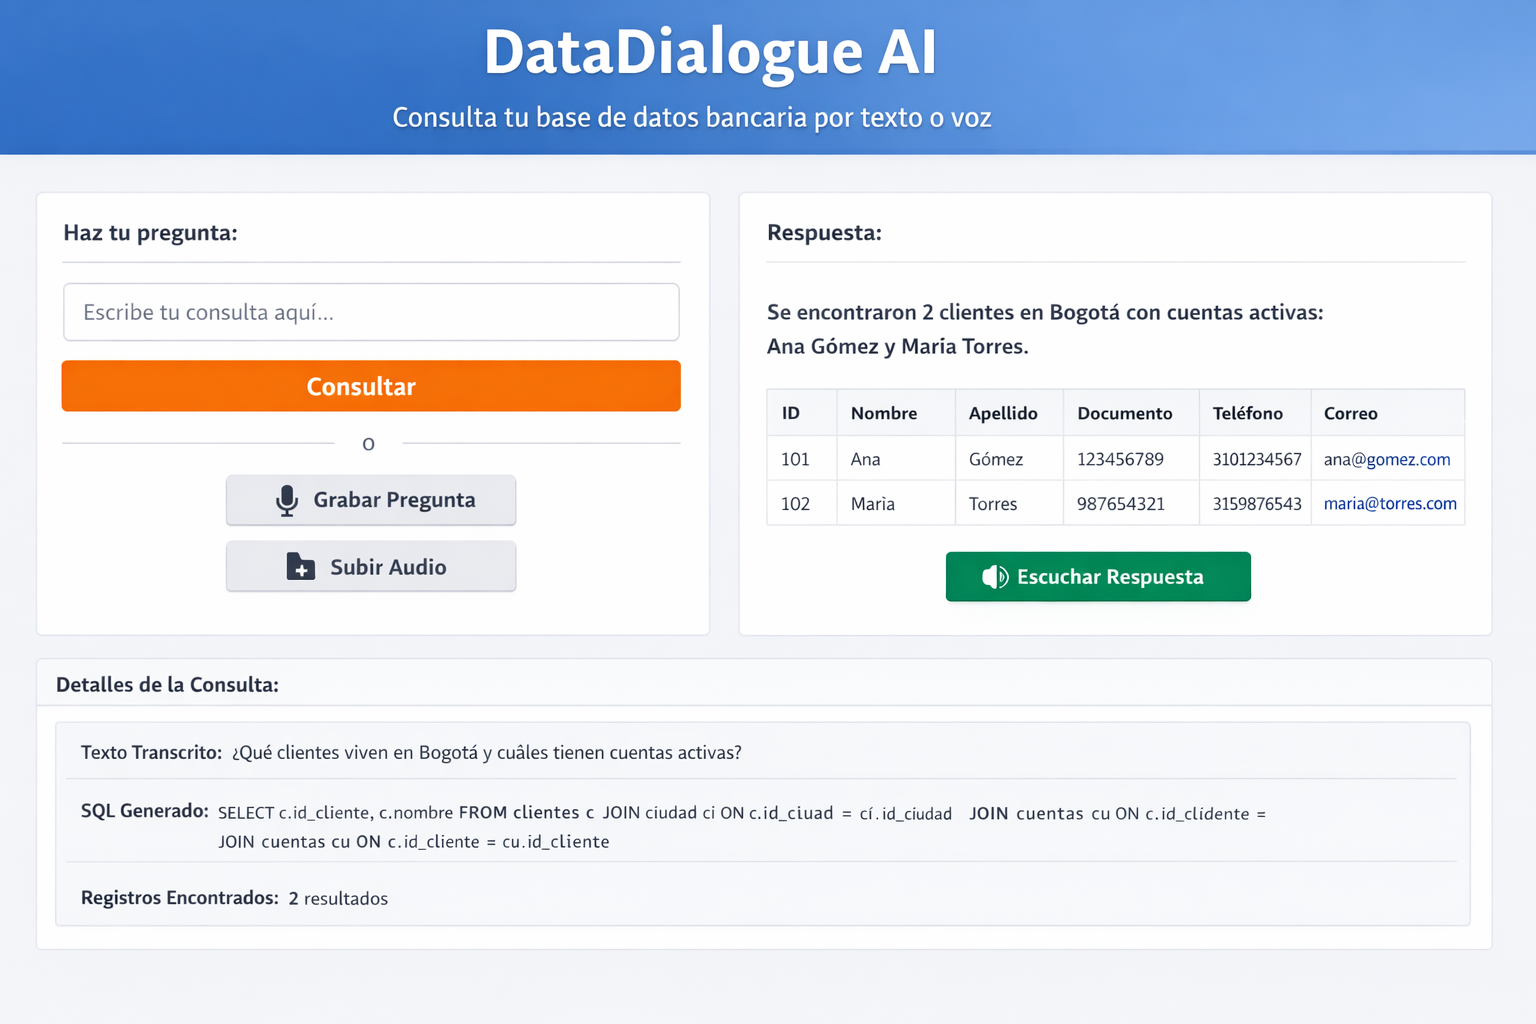

# **Descripción:**

Diseñar e implementar una aplicación llamada DataDialogue AI que permita a cualquier usuario consultar una base de datos bancaria mediante lenguaje natural (texto o voz), sin necesidad de conocer SQL.

🧠 Contexto del reto

El desarrollo de software ya no se limita a construir sistemas funcionales; hoy exige repensar la forma en que los usuarios interactúan con la información.

En este reto, transformarás una base de datos tradicional en un sistema conversacional, accesible e inteligente.

⚙️ ¿Qué debes construir?

Una aplicación que permita:

1. Interacción por texto

El usuario escribe preguntas como:

¿Qué clientes viven en Bogotá?
¿Cuál es el saldo total por ciudad?
¿Qué movimientos tiene un cliente?

Y el sistema:

interpreta la pregunta
genera SQL automáticamente
consulta la base de datos
responde en lenguaje natural
2. Interacción por voz

El usuario puede:

grabar o cargar un audio

Y el sistema:

transcribe la voz
convierte a texto
ejecuta la consulta
responde en texto y opcionalmente en audio
3. Visualización de resultados

La aplicación debe mostrar:

🧾 Respuesta natural (explicativa)
📊 Tabla con los resultados
🧠 SQL generado (trazabilidad)
🎧 Opción de escuchar la respuesta
4. Trazabilidad del proceso

El sistema debe evidenciar:

texto transcrito (si aplica)
SQL generado
número de registros encontrados
🏗️ Arquitectura esperada

Tu solución debe integrar:

Base de datos relacional (SQLite)
Capa semántica (NL → SQL con IA)
Procesamiento de voz (Whisper)
Síntesis de voz (gTTS)
Interfaz (Streamlit)
💡 Lo que debes demostrar

Este reto no evalúa solo código. Evalúa tu capacidad de:

convertir una BD en un sistema conversacional
integrar múltiples tecnologías en un flujo coherente
mejorar la experiencia de usuario
construir soluciones alineadas con la evolución del desarrollo de software
🧪 Resultado esperado

Una aplicación funcional donde:

👉 un usuario pueda hablar o escribir
👉 el sistema entienda
👉 consulte la base de datos
👉 y responda de forma clara, trazable y útil

🔥 Nivel diferencial (reto avanzado)

Si quieres destacarte:

agrega historial conversacional
mejora la precisión semántica (valores controlados)
maneja errores inteligentemente
optimiza la experiencia visual
incluye indicadores o insights automáticos